## NSL-KDD Datset Preview (Split Training and Testing)

In [5]:
import pandas as pd
import numpy as np
import os

# Define the dataset folder path
DATASET_FOLDER = "../raw/NSL_KDD_DATASET/"

# Define the column names for NSL-KDD TXT files
# 41 features + attack_type + difficulty_level (43 columns total)
column_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
    'num_root', 'num_file_creations', 'num_shells', 'num_access_files',
    'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
    'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
    'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'attack_type', 'difficulty_level'
]

def load_nsl_kdd_txt(file_path):
    """
    Load NSL-KDD dataset from a TXT file
    
    Args:
        file_path (str): Path to the NSL-KDD TXT file
    
    Returns:
        pandas.DataFrame: Loaded dataset with proper column names
    """
    try:
        # Load the data - NSL-KDD TXT files are comma-separated
        df = pd.read_csv(file_path, names=column_names, skipinitialspace=True)
        
        # Remove any trailing periods from attack_type column
        if 'attack_type' in df.columns:
            df['attack_type'] = df['attack_type'].str.rstrip('.')
        
        return df
    
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        return None
    except Exception as e:
        print(f"Error loading file: {e}")
        return None

def preview_dataset(df, dataset_name="Dataset", n_rows=5):
    """
    Preview the NSL-KDD dataset with useful information
    
    Args:
        df (pandas.DataFrame): The loaded dataset
        dataset_name (str): Name of the dataset for display
        n_rows (int): Number of rows to display
    """
    if df is None:
        print(f"No {dataset_name} to preview")
        return
    
    print(f"=== {dataset_name} Preview ===")
    print(f"Dataset shape: {df.shape}")
    print(f"\n=== First {n_rows} rows ===")
    print(df.head(n_rows))
    
    print(f"\n=== Data types ===")
    print(df.dtypes)
    
    print(f"\n=== Attack type distribution ===")
    print(df['attack_type'].value_counts())
    
    print(f"\n=== Difficulty level distribution ===")
    print(df['difficulty_level'].value_counts())
    
    print(f"\n=== Missing values ===")
    missing_count = df.isnull().sum().sum()
    print(f"Total missing values: {missing_count}")
    
    print(f"\n=== Basic statistics for numerical columns ===")
    print(df.describe())

def analyze_categorical_features(df, dataset_name="Dataset"):
    """Analyze categorical features in the dataset"""
    categorical_cols = ['protocol_type', 'service', 'flag', 'attack_type', 'difficulty_level']
    
    print(f"\n=== {dataset_name} Categorical Features Analysis ===")
    for col in categorical_cols:
        if col in df.columns:
            print(f"\n--- {col.upper()} ---")
            print(f"Number of unique values: {df[col].nunique()}")
            print("Top 10 values:")
            print(df[col].value_counts().head(10))

def analyze_label_distribution(train_data, test_data):
    """
    Analyze and compare label distributions between training and testing datasets
    
    Args:
        train_data (pandas.DataFrame): Training dataset
        test_data (pandas.DataFrame): Testing dataset
    """
    if train_data is None or test_data is None:
        print("Cannot analyze label distribution - missing data")
        return
    
    print("=== ATTACK TYPE DISTRIBUTION ===")
    
    # Get attack type distributions
    train_attacks = train_data['attack_type'].value_counts().sort_index()
    test_attacks = test_data['attack_type'].value_counts().sort_index()
    
    # Create a comprehensive comparison
    all_attacks = sorted(set(train_attacks.index) | set(test_attacks.index))
    
    print(f"{'Attack Type':<20} {'Train Count':<12} {'Train %':<10} {'Test Count':<12} {'Test %':<10}")
    print("-" * 75)
    
    for attack in all_attacks:
        train_count = train_attacks.get(attack, 0)
        test_count = test_attacks.get(attack, 0)
        train_pct = (train_count / len(train_data)) * 100
        test_pct = (test_count / len(test_data)) * 100
        
        print(f"{attack:<20} {train_count:<12} {train_pct:<10.2f} {test_count:<12} {test_pct:<10.2f}")
    
    # Binary classification analysis
    print(f"\n=== BINARY CLASSIFICATION (Normal vs Attack) ===")
    
    train_normal = (train_data['attack_type'] == 'normal').sum()
    train_attack = len(train_data) - train_normal
    test_normal = (test_data['attack_type'] == 'normal').sum()
    test_attack = len(test_data) - test_normal
    
    print(f"{'Class':<10} {'Train Count':<12} {'Train %':<10} {'Test Count':<12} {'Test %':<10}")
    print("-" * 60)
    print(f"{'Normal':<10} {train_normal:<12} {(train_normal/len(train_data)*100):<10.2f} {test_normal:<12} {(test_normal/len(test_data)*100):<10.2f}")
    print(f"{'Attack':<10} {train_attack:<12} {(train_attack/len(train_data)*100):<10.2f} {test_attack:<12} {(test_attack/len(test_data)*100):<10.2f}")
    
    # Attack category analysis
    print(f"\n=== ATTACK CATEGORY DISTRIBUTION ===")
    
    def categorize_attack(attack_type):
        """Categorize attacks into main types"""
        dos_attacks = ['back', 'land', 'neptune', 'pod', 'smurf', 'teardrop', 'apache2', 'udpstorm', 'processtable', 'worm']
        probe_attacks = ['ipsweep', 'nmap', 'portsweep', 'satan', 'mscan', 'saint']
        r2l_attacks = ['ftp_write', 'guess_passwd', 'imap', 'multihop', 'phf', 'spy', 'warezclient', 'warezmaster', 
                       'sendmail', 'named', 'snmpgetattack', 'snmpguess', 'xlock', 'xsnoop', 'httptunnel']
        u2r_attacks = ['buffer_overflow', 'loadmodule', 'perl', 'rootkit', 'ps', 'sqlattack', 'xterm']
        
        if attack_type == 'normal':
            return 'Normal'
        elif attack_type in dos_attacks:
            return 'DoS'
        elif attack_type in probe_attacks:
            return 'Probe'
        elif attack_type in r2l_attacks:
            return 'R2L'
        elif attack_type in u2r_attacks:
            return 'U2R'
        else:
            return 'Other'
    
    # Apply categorization
    train_categories = train_data['attack_type'].apply(categorize_attack).value_counts()
    test_categories = test_data['attack_type'].apply(categorize_attack).value_counts()
    
    all_categories = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R', 'Other']
    
    print(f"{'Category':<10} {'Train Count':<12} {'Train %':<10} {'Test Count':<12} {'Test %':<10}")
    print("-" * 60)
    
    for category in all_categories:
        train_count = train_categories.get(category, 0)
        test_count = test_categories.get(category, 0)
        if train_count > 0 or test_count > 0:  # Only show categories that exist
            train_pct = (train_count / len(train_data)) * 100
            test_pct = (test_count / len(test_data)) * 100
            print(f"{category:<10} {train_count:<12} {train_pct:<10.2f} {test_count:<12} {test_pct:<10.2f}")
    
    # Summary statistics
    print(f"\n=== SUMMARY STATISTICS ===")
    print(f"Total training samples: {len(train_data):,}")
    print(f"Total testing samples: {len(test_data):,}")
    print(f"Unique attack types in training: {train_data['attack_type'].nunique()}")
    print(f"Unique attack types in testing: {test_data['attack_type'].nunique()}")
    print(f"Attack types only in training: {set(train_attacks.index) - set(test_attacks.index)}")
    print(f"Attack types only in testing: {set(test_attacks.index) - set(train_attacks.index)}")

def create_binary_labels(df):
    """Create binary labels (normal vs attack) from attack_type column"""
    if 'attack_type' not in df.columns:
        print("No attack_type column found. Cannot create binary labels.")
        return df
    
    df_copy = df.copy()
    df_copy['is_attack'] = (df_copy['attack_type'] != 'normal').astype(int)
    return df_copy

def load_train_test_data():
    """
    Load training and testing data from NSL-KDD TXT files
    
    Returns:
        tuple: (train_data, test_data) pandas DataFrames
    """
    print("Loading NSL-KDD Training and Testing Data...")
    print("-" * 50)
    
    # Load training data
    train_file = os.path.join(DATASET_FOLDER, "KDDTrain+.TXT")
    print(f"Loading training data from: {train_file}")
    train_data = load_nsl_kdd_txt(train_file)
    
    if train_data is not None:
        print(f"✓ Training data loaded successfully: {train_data.shape}")
    else:
        print("✗ Failed to load training data")
    
    # Load test data
    test_file = os.path.join(DATASET_FOLDER, "KDDTest+.TXT")
    print(f"Loading test data from: {test_file}")
    test_data = load_nsl_kdd_txt(test_file)
    
    if test_data is not None:
        print(f"✓ Test data loaded successfully: {test_data.shape}")
    else:
        print("✗ Failed to load test data")
    
    return train_data, test_data

# Main execution
if __name__ == "__main__":
    # Load training and testing data
    train_data, test_data = load_train_test_data()
    
    # Preview training data
    if train_data is not None:
        print(f"\n{'='*60}")
        print("TRAINING DATA")
        print('='*60)
        preview_dataset(train_data, "Training Data", n_rows=3)
    
    # Preview test data
    if test_data is not None:
        print(f"\n{'='*60}")
        print("TESTING DATA")
        print('='*60)
        preview_dataset(test_data, "Testing Data", n_rows=3)
    
    # Data summary
    if train_data is not None and test_data is not None:
        print(f"\n{'='*60}")
        print("DATA SUMMARY")
        print('='*60)
        print(f"Training data shape: {train_data.shape}")
        print(f"Testing data shape: {test_data.shape}")
        print(f"Total samples: {train_data.shape[0] + test_data.shape[0]}")
        
        # Compare attack distributions
        print(f"\nTraining set attack distribution:")
        train_attacks = train_data['attack_type'].value_counts()
        print(f"Normal: {train_attacks.get('normal', 0)}")
        print(f"Attacks: {train_data.shape[0] - train_attacks.get('normal', 0)}")
        
        print(f"\nTesting set attack distribution:")
        test_attacks = test_data['attack_type'].value_counts()
        print(f"Normal: {test_attacks.get('normal', 0)}")
        print(f"Attacks: {test_data.shape[0] - test_attacks.get('normal', 0)}")
        
        # Detailed label distribution analysis
        print(f"\n{'='*60}")
        print("DETAILED LABEL DISTRIBUTION ANALYSIS")
        print('='*60)
        
        analyze_label_distribution(train_data, test_data)

Loading NSL-KDD Training and Testing Data...
--------------------------------------------------
Loading training data from: ../raw/NSL_KDD_DATASET/KDDTrain+.TXT
✓ Training data loaded successfully: (125973, 43)
Loading test data from: ../raw/NSL_KDD_DATASET/KDDTest+.TXT
✓ Test data loaded successfully: (22544, 43)

TRAINING DATA
=== Training Data Preview ===
Dataset shape: (125973, 43)

=== First 3 rows ===
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   

   dst_host_diff_srv_rate  dst_host_same_src_po

## Distribution

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch

# Set style for better-looking plots
plt.style.use('default')
sns.set_palette("husl")

def categorize_attack(attack_type):
    """Categorize attacks into main types with color coding"""
    dos_attacks = ['back', 'land', 'neptune', 'pod', 'smurf', 'teardrop', 'apache2', 'udpstorm', 'processtable', 'worm']
    probe_attacks = ['ipsweep', 'nmap', 'portsweep', 'satan', 'mscan', 'saint']
    r2l_attacks = ['ftp_write', 'guess_passwd', 'imap', 'multihop', 'phf', 'spy', 'warezclient', 'warezmaster', 
                   'sendmail', 'named', 'snmpgetattack', 'snmpguess', 'xlock', 'xsnoop', 'httptunnel']
    u2r_attacks = ['buffer_overflow', 'loadmodule', 'perl', 'rootkit', 'ps', 'sqlattack', 'xterm']
    
    if attack_type == 'normal':
        return 'Normal'
    elif attack_type in dos_attacks:
        return 'DoS'
    elif attack_type in probe_attacks:
        return 'Probe'
    elif attack_type in r2l_attacks:
        return 'R2L'
    elif attack_type in u2r_attacks:
        return 'U2R'
    else:
        return 'Other'

def get_category_colors():
    """Define consistent colors for each attack category"""
    return {
        'Normal': '#2ecc71',    # Green
        'DoS': '#e74c3c',       # Red
        'Probe': '#f39c12',     # Orange
        'R2L': '#9b59b6',       # Purple
        'U2R': '#34495e',       # Dark gray
        'Other': '#95a5a6'      # Light gray
    }

def plot_attack_distribution(train_data, test_data, save_plots=False):
    """
    Create comprehensive visualizations for attack type distributions
    
    Args:
        train_data (pd.DataFrame): Training dataset
        test_data (pd.DataFrame): Testing dataset
        save_plots (bool): Whether to save plots to files
    """
    
    # Set up the plotting style
    plt.rcParams['figure.figsize'] = (15, 10)
    plt.rcParams['font.size'] = 10
    
    # Create subplots
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Binary Distribution (Normal vs Attack)
    ax1 = plt.subplot(2, 3, 1)
    plot_binary_distribution(train_data, test_data, ax1)
    
    # 2. Attack Category Distribution
    ax2 = plt.subplot(2, 3, 2)
    plot_category_distribution(train_data, test_data, ax2)
    
    # 3. Top Attack Types Comparison
    ax3 = plt.subplot(2, 3, 3)
    plot_top_attacks(train_data, test_data, ax3)
    
    # 4. Training Set Attack Types (detailed)
    ax4 = plt.subplot(2, 3, 4)
    plot_detailed_attacks(train_data, 'Training Set', ax4)
    
    # 5. Testing Set Attack Types (detailed)
    ax5 = plt.subplot(2, 3, 5)
    plot_detailed_attacks(test_data, 'Testing Set', ax5)
    
    # 6. Heatmap comparison
    ax6 = plt.subplot(2, 3, 6)
    plot_comparison_heatmap(train_data, test_data, ax6)
    
    plt.tight_layout(pad=3.0)
    plt.suptitle('NSL-KDD Dataset Attack Type Distribution Analysis', fontsize=16, y=0.98)
    
    if save_plots:
        plt.savefig('nsl_kdd_attack_distribution.png', dpi=300, bbox_inches='tight')
        print("Plot saved as 'nsl_kdd_attack_distribution.png'")
    
    plt.show()

def plot_binary_distribution(train_data, test_data, ax):
    """Plot binary classification distribution"""
    # Calculate binary distributions
    train_normal = (train_data['attack_type'] == 'normal').sum()
    train_attack = len(train_data) - train_normal
    test_normal = (test_data['attack_type'] == 'normal').sum()
    test_attack = len(test_data) - test_normal
    
    categories = ['Normal', 'Attack']
    train_counts = [train_normal, train_attack]
    test_counts = [test_normal, test_attack]
    
    x = np.arange(len(categories))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, train_counts, width, label='Training', alpha=0.8, color='skyblue')
    bars2 = ax.bar(x + width/2, test_counts, width, label='Testing', alpha=0.8, color='lightcoral')
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 500,
                   f'{int(height):,}', ha='center', va='bottom', fontsize=9)
    
    ax.set_title('Binary Classification Distribution\n(Normal vs Attack)', fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel('Number of Samples')
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

def plot_category_distribution(train_data, test_data, ax):
    """Plot attack category distribution"""
    colors = get_category_colors()
    
    # Apply categorization
    train_categories = train_data['attack_type'].apply(categorize_attack).value_counts()
    test_categories = test_data['attack_type'].apply(categorize_attack).value_counts()
    
    # Get all categories
    all_categories = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R', 'Other']
    train_counts = [train_categories.get(cat, 0) for cat in all_categories]
    test_counts = [test_categories.get(cat, 0) for cat in all_categories]
    
    x = np.arange(len(all_categories))
    width = 0.35
    
    category_colors = [colors[cat] for cat in all_categories]
    
    bars1 = ax.bar(x - width/2, train_counts, width, label='Training', alpha=0.8, color=category_colors)
    bars2 = ax.bar(x + width/2, test_counts, width, label='Testing', alpha=0.6, color=category_colors)
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height + 200,
                       f'{int(height):,}', ha='center', va='bottom', fontsize=8, rotation=45)
    
    ax.set_title('Attack Category Distribution', fontweight='bold')
    ax.set_xlabel('Attack Category')
    ax.set_ylabel('Number of Samples')
    ax.set_xticks(x)
    ax.set_xticklabels(all_categories, rotation=45)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

def plot_top_attacks(train_data, test_data, ax):
    """Plot top 10 attack types comparison"""
    # Get top 10 attacks from training data
    train_attacks = train_data['attack_type'].value_counts().head(10)
    test_attacks = test_data['attack_type'].value_counts()
    
    attack_types = train_attacks.index
    train_counts = train_attacks.values
    test_counts = [test_attacks.get(attack, 0) for attack in attack_types]
    
    x = np.arange(len(attack_types))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, train_counts, width, label='Training', alpha=0.8, color='steelblue')
    bars2 = ax.bar(x + width/2, test_counts, width, label='Testing', alpha=0.8, color='darkorange')
    
    ax.set_title('Top 10 Attack Types Comparison', fontweight='bold')
    ax.set_xlabel('Attack Type')
    ax.set_ylabel('Number of Samples (log scale)')
    ax.set_yscale('log')
    ax.set_xticks(x)
    ax.set_xticklabels(attack_types, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

def plot_detailed_attacks(data, dataset_name, ax):
    """Plot detailed attack distribution for a single dataset"""
    colors = get_category_colors()
    
    # Get attack distribution
    attack_dist = data['attack_type'].value_counts()
    
    # Apply categorization for coloring
    categories = [categorize_attack(attack) for attack in attack_dist.index]
    bar_colors = [colors[cat] for cat in categories]
    
    # Limit to top 15 for readability
    top_attacks = attack_dist.head(15)
    top_categories = categories[:15]
    top_colors = bar_colors[:15]
    
    bars = ax.bar(range(len(top_attacks)), top_attacks.values, color=top_colors, alpha=0.8)
    
    ax.set_title(f'{dataset_name} - Top 15 Attack Types', fontweight='bold')
    ax.set_xlabel('Attack Type')
    ax.set_ylabel('Number of Samples')
    ax.set_xticks(range(len(top_attacks)))
    ax.set_xticklabels(top_attacks.index, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels for top 5
    for i, bar in enumerate(bars[:5]):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
               f'{int(height):,}', ha='center', va='bottom', fontsize=8)

def plot_comparison_heatmap(train_data, test_data, ax):
    """Create a heatmap comparing attack distributions"""
    # Get all unique attacks
    all_attacks = sorted(set(train_data['attack_type'].unique()) | set(test_data['attack_type'].unique()))
    
    # Create comparison matrix
    train_counts = train_data['attack_type'].value_counts()
    test_counts = test_data['attack_type'].value_counts()
    
    # Normalize by dataset size for fair comparison
    train_pct = (train_counts / len(train_data) * 100)
    test_pct = (test_counts / len(test_data) * 100)
    
    # Create matrix for top 15 attacks
    top_attacks = train_counts.head(15).index
    comparison_data = []
    
    for attack in top_attacks:
        comparison_data.append([
            train_pct.get(attack, 0),
            test_pct.get(attack, 0)
        ])
    
    comparison_matrix = np.array(comparison_data)
    
    # Create heatmap
    im = ax.imshow(comparison_matrix.T, cmap='YlOrRd', aspect='auto')
    
    # Set ticks and labels
    ax.set_xticks(range(len(top_attacks)))
    ax.set_xticklabels(top_attacks, rotation=45, ha='right')
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Training', 'Testing'])
    ax.set_title('Attack Distribution Heatmap\n(Percentage of Dataset)', fontweight='bold')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Percentage (%)')
    
    # Add text annotations
    for i in range(len(top_attacks)):
        for j in range(2):
            text = ax.text(i, j, f'{comparison_matrix[i, j]:.1f}%',
                         ha="center", va="center", color="black" if comparison_matrix[i, j] < 50 else "white",
                         fontsize=8)

def create_individual_plots(train_data, test_data, save_plots=False):
    """Create individual plots for more detailed analysis"""
    
    # 1. Pie charts for category distribution
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    colors = get_category_colors()
    
    # Training set pie chart
    train_categories = train_data['attack_type'].apply(categorize_attack).value_counts()
    pie_colors = [colors[cat] for cat in train_categories.index]
    
    wedges1, texts1, autotexts1 = ax1.pie(train_categories.values, labels=train_categories.index, 
                                          autopct='%1.1f%%', colors=pie_colors, startangle=90)
    ax1.set_title('Training Set - Attack Categories', fontweight='bold', fontsize=14)
    
    # Testing set pie chart
    test_categories = test_data['attack_type'].apply(categorize_attack).value_counts()
    pie_colors2 = [colors[cat] for cat in test_categories.index]
    
    wedges2, texts2, autotexts2 = ax2.pie(test_categories.values, labels=test_categories.index, 
                                          autopct='%1.1f%%', colors=pie_colors2, startangle=90)
    ax2.set_title('Testing Set - Attack Categories', fontweight='bold', fontsize=14)
    
    plt.tight_layout()
    
    if save_plots:
        plt.savefig('nsl_kdd_category_pies.png', dpi=300, bbox_inches='tight')
        print("Category pie charts saved as 'nsl_kdd_category_pies.png'")
    
    plt.show()
    
    # 2. Detailed bar chart for all attack types
    fig, ax = plt.subplots(figsize=(20, 8))
    
    # Get all unique attacks and their counts
    all_attacks = sorted(set(train_data['attack_type'].unique()) | set(test_data['attack_type'].unique()))
    train_counts = train_data['attack_type'].value_counts()
    test_counts = test_data['attack_type'].value_counts()
    
    train_values = [train_counts.get(attack, 0) for attack in all_attacks]
    test_values = [test_counts.get(attack, 0) for attack in all_attacks]
    
    x = np.arange(len(all_attacks))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, train_values, width, label='Training', alpha=0.8, color='steelblue')
    bars2 = ax.bar(x + width/2, test_values, width, label='Testing', alpha=0.8, color='darkorange')
    
    ax.set_title('Complete Attack Type Distribution Comparison', fontweight='bold', fontsize=16)
    ax.set_xlabel('Attack Type', fontsize=12)
    ax.set_ylabel('Number of Samples (log scale)', fontsize=12)
    ax.set_yscale('log')
    ax.set_xticks(x)
    ax.set_xticklabels(all_attacks, rotation=45, ha='right')
    ax.legend(fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    if save_plots:
        plt.savefig('nsl_kdd_complete_distribution.png', dpi=300, bbox_inches='tight')
        print("Complete distribution chart saved as 'nsl_kdd_complete_distribution.png'")
    
    plt.show()

# Example usage
if __name__ == "__main__":
    # Note: You need to have train_data and test_data loaded
    # This script assumes you've run the previous data loading script
    
    print("NSL-KDD Attack Type Visualization")
    print("=" * 50)
    print("Make sure you have train_data and test_data loaded before running this script.")
    print("\nTo use this script:")
    print("1. First run the data loading script to get train_data and test_data")
    print("2. Then call: plot_attack_distribution(train_data, test_data)")
    print("3. Or call: create_individual_plots(train_data, test_data)")
    print("\nExample:")
    print("plot_attack_distribution(train_data, test_data, save_plots=True)")
    print("create_individual_plots(train_data, test_data, save_plots=True)")

NSL-KDD Attack Type Visualization
Make sure you have train_data and test_data loaded before running this script.

To use this script:
1. First run the data loading script to get train_data and test_data
2. Then call: plot_attack_distribution(train_data, test_data)
3. Or call: create_individual_plots(train_data, test_data)

Example:
plot_attack_distribution(train_data, test_data, save_plots=True)
create_individual_plots(train_data, test_data, save_plots=True)


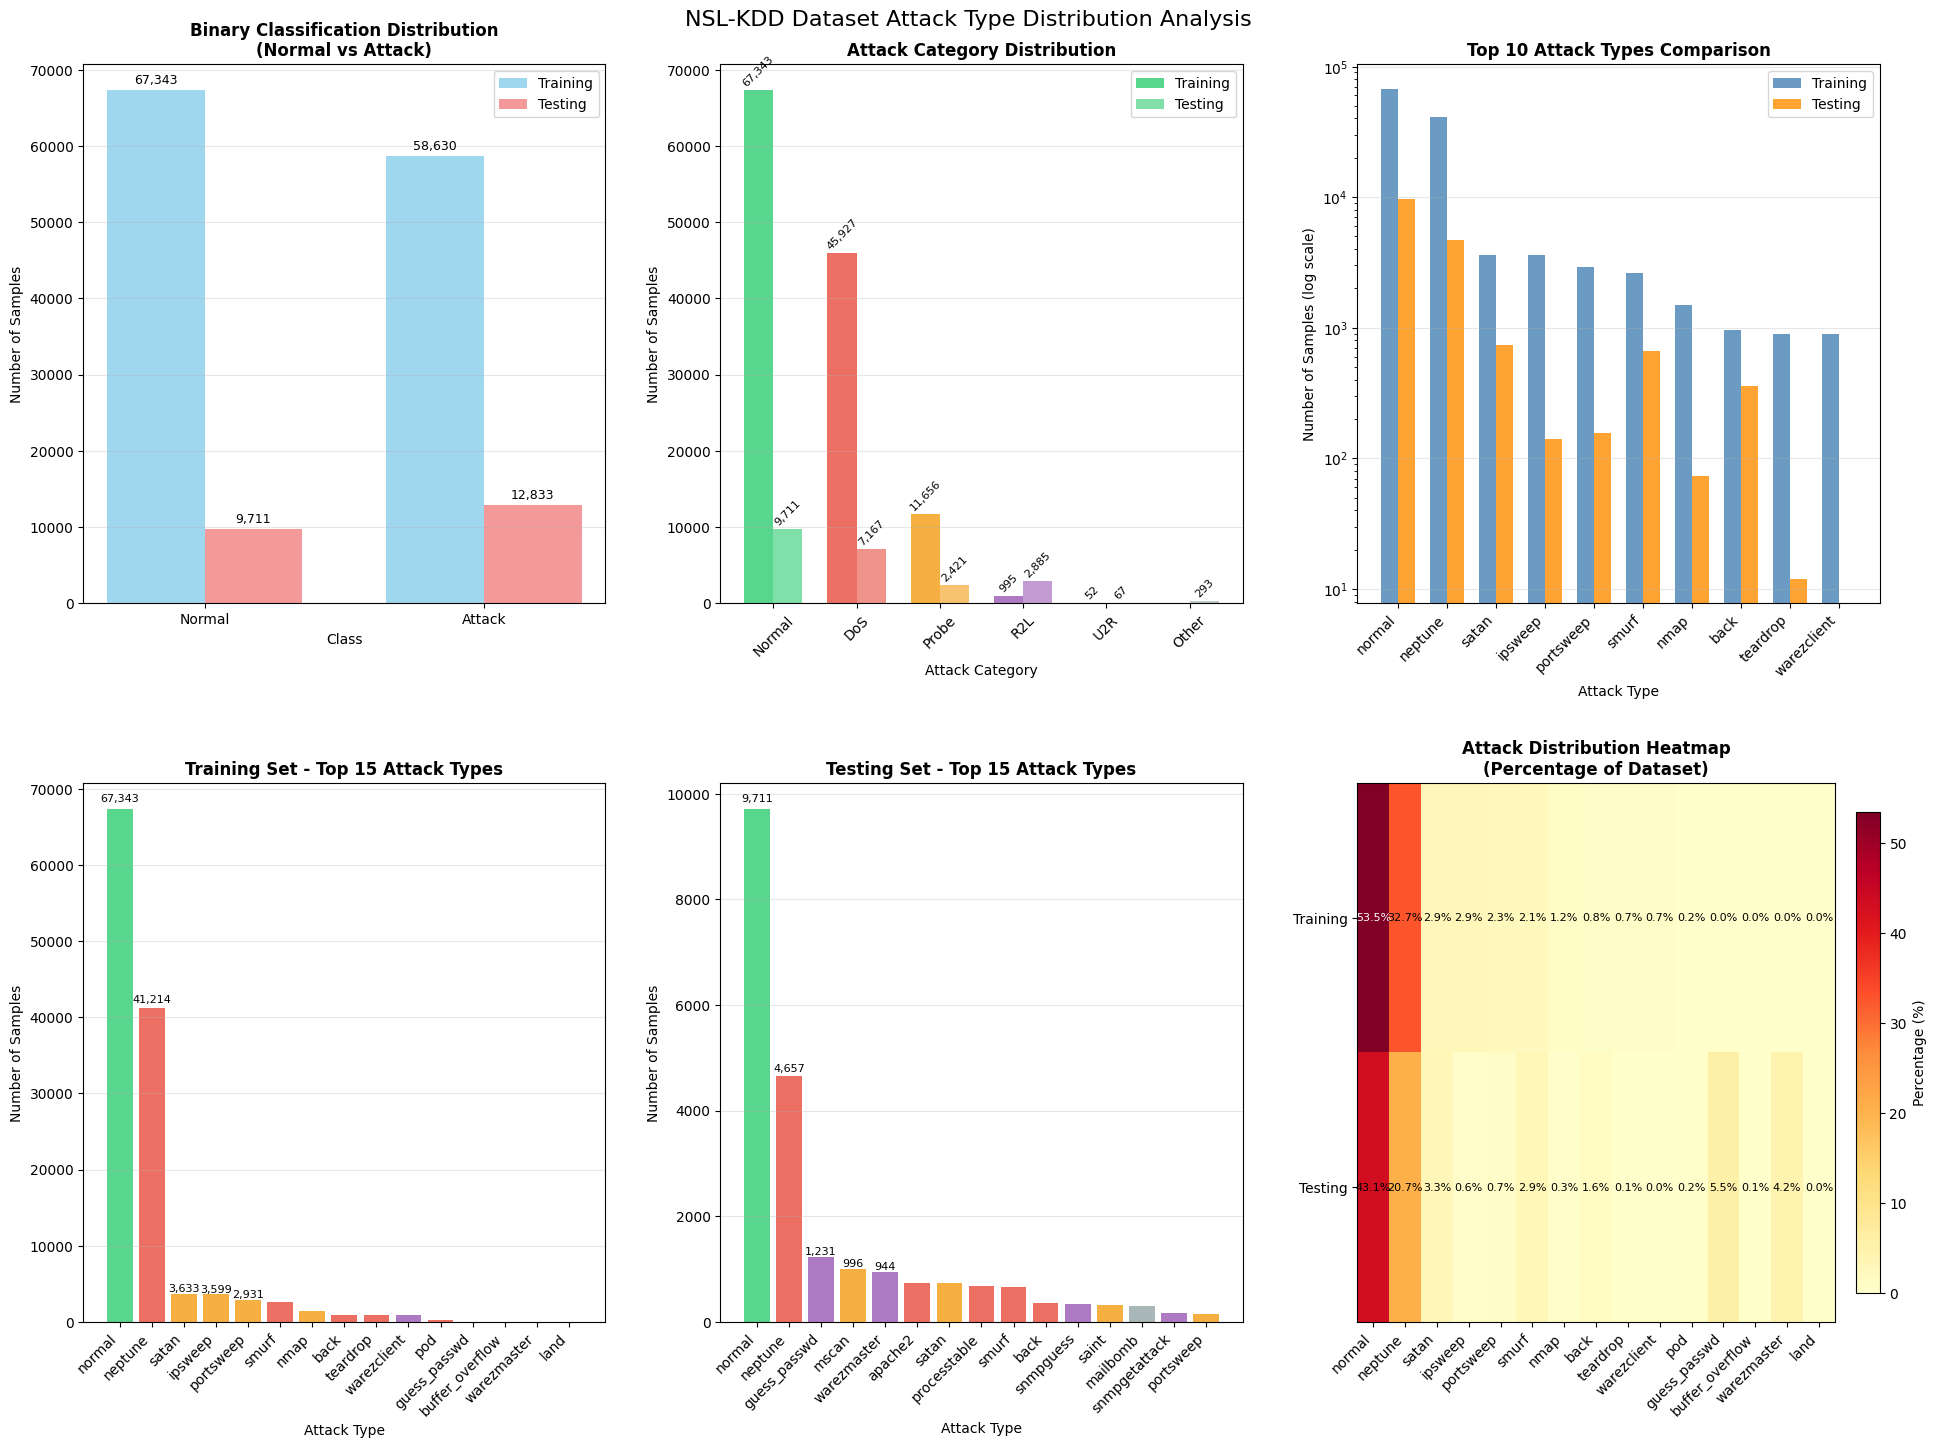

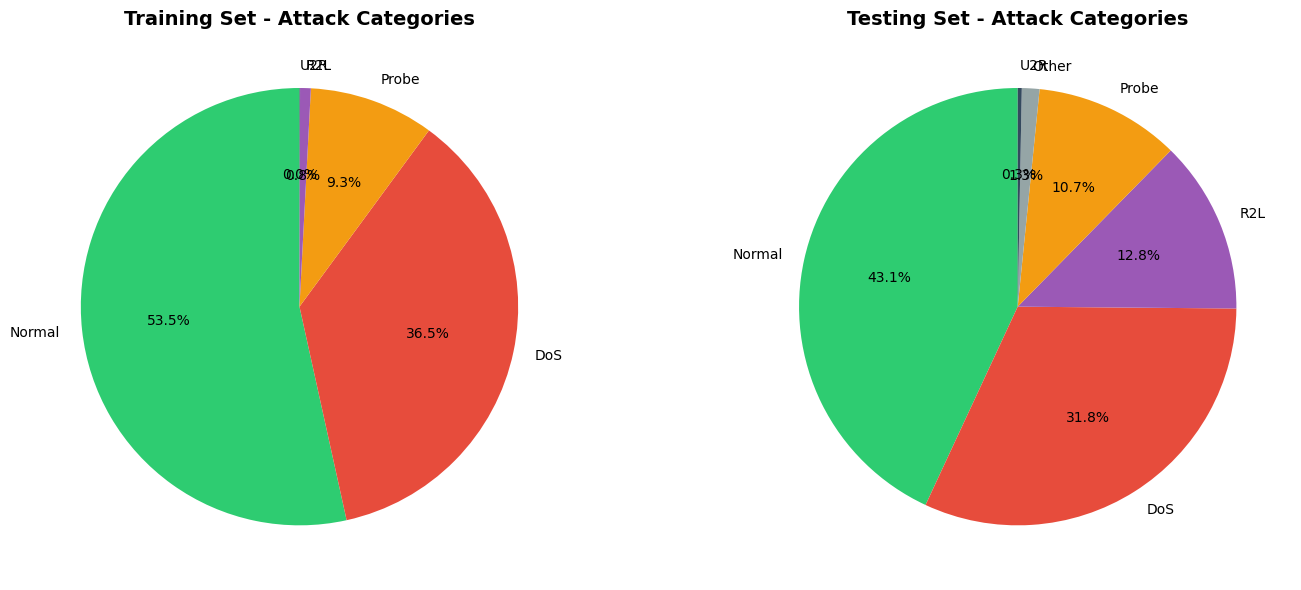

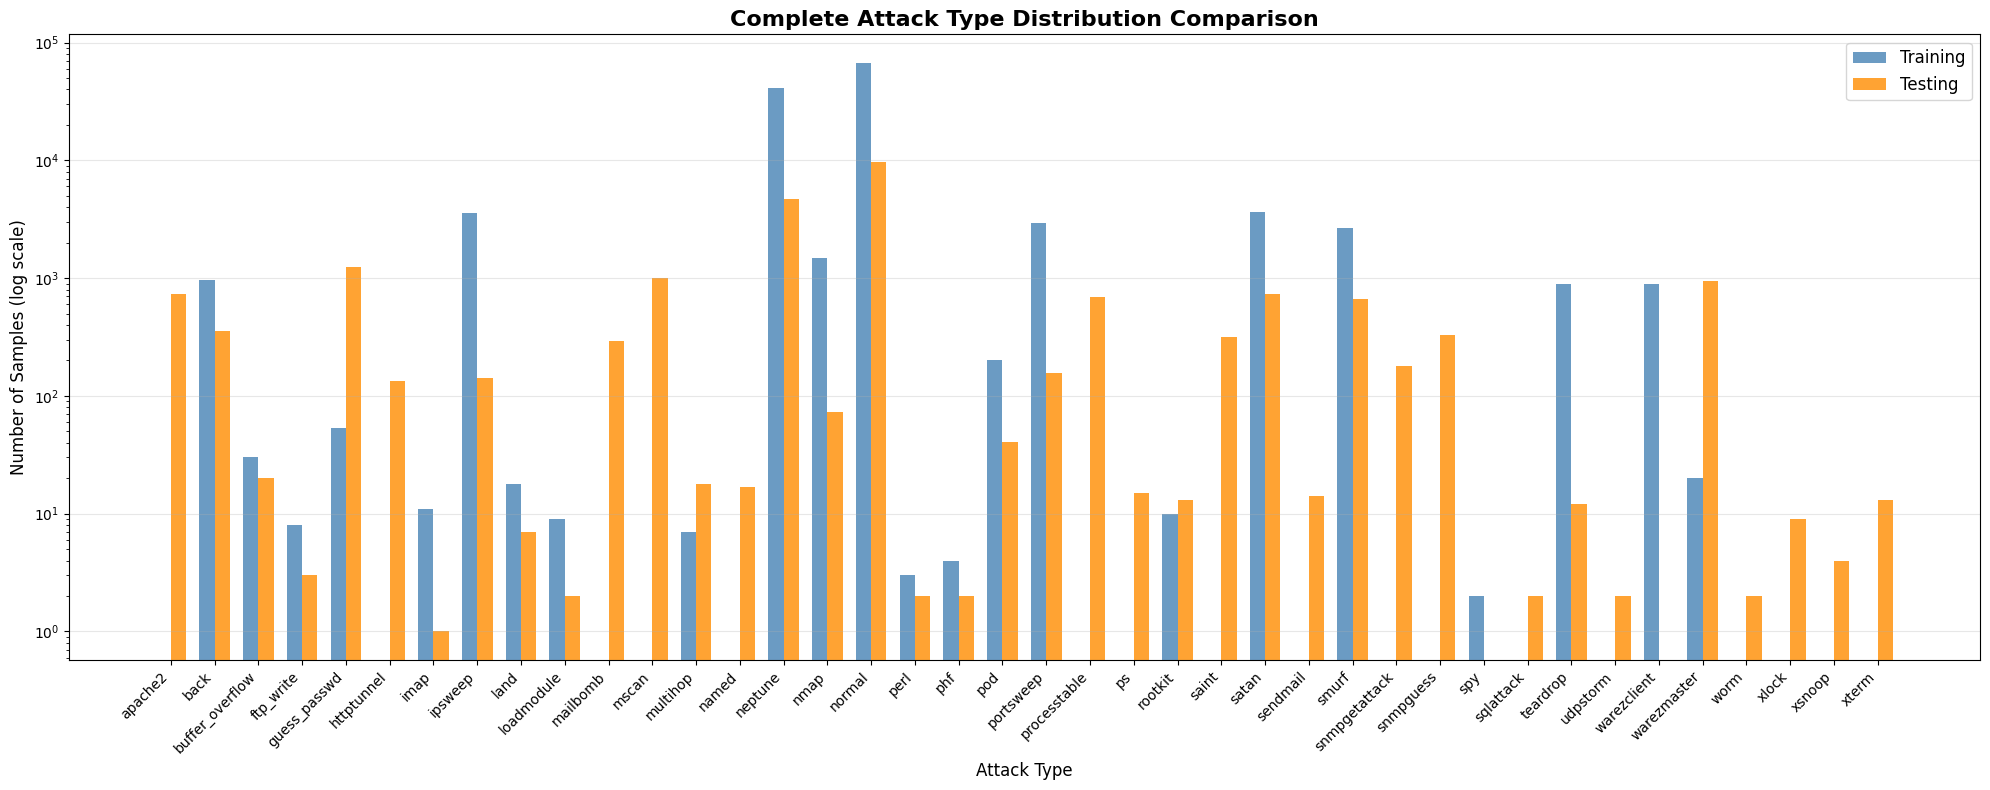

In [8]:
plot_attack_distribution(train_data, test_data, save_plots=False)
create_individual_plots(train_data, test_data, save_plots=False)

## Rare Attacks

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import defaultdict

# Set style for better-looking plots
plt.style.use('default')
sns.set_palette("husl")

def get_attack_categories():
    """Define attack categories with their specific attack types"""
    return {
        'DoS': ['back', 'land', 'neptune', 'pod', 'smurf', 'teardrop', 'apache2', 'udpstorm', 'processtable', 'worm'],
        'Probe': ['ipsweep', 'nmap', 'portsweep', 'satan', 'mscan', 'saint'],
        'R2L': ['ftp_write', 'guess_passwd', 'imap', 'multihop', 'phf', 'spy', 'warezclient', 'warezmaster', 
                'sendmail', 'named', 'snmpgetattack', 'snmpguess', 'xlock', 'xsnoop', 'httptunnel'],
        'U2R': ['buffer_overflow', 'loadmodule', 'perl', 'rootkit', 'ps', 'sqlattack', 'xterm']
    }

def get_category_colors():
    """Define colors for each attack category"""
    return {
        'DoS': '#e74c3c',       # Red
        'Probe': '#f39c12',     # Orange
        'R2L': '#9b59b6',       # Purple
        'U2R': '#34495e'        # Dark gray
    }

def categorize_attack_detailed(attack_type):
    """Categorize attacks into detailed types"""
    categories = get_attack_categories()
    
    for category, attacks in categories.items():
        if attack_type in attacks:
            return category
    return None  # Not one of the target categories

def analyze_rare_attacks(train_data, test_data):
    """
    Analyze the distribution of rare attack types (DoS, Probe, R2L, U2R)
    
    Args:
        train_data (pd.DataFrame): Training dataset
        test_data (pd.DataFrame): Testing dataset
    
    Returns:
        dict: Analysis results for both datasets
    """
    categories = get_attack_categories()
    results = {
        'train': defaultdict(dict),
        'test': defaultdict(dict)
    }
    
    datasets = {'train': train_data, 'test': test_data}
    
    print("=" * 80)
    print("RARE ATTACK TYPES DETAILED ANALYSIS")
    print("=" * 80)
    
    for dataset_name, data in datasets.items():
        print(f"\n{'='*20} {dataset_name.upper()} DATASET {'='*20}")
        
        total_samples = len(data)
        total_attacks = 0
        
        for category, attack_list in categories.items():
            category_total = 0
            print(f"\n--- {category} ATTACKS ---")
            
            for attack in attack_list:
                count = (data['attack_type'] == attack).sum()
                if count > 0:
                    percentage = (count / total_samples) * 100
                    print(f"{attack:<20}: {count:>8,} ({percentage:>6.3f}%)")
                    results[dataset_name][category][attack] = count
                    category_total += count
                else:
                    print(f"{attack:<20}: {count:>8,} ({0:>6.3f}%)")
                    results[dataset_name][category][attack] = 0
            
            total_attacks += category_total
            category_percentage = (category_total / total_samples) * 100
            print(f"{'TOTAL ' + category:<20}: {category_total:>8,} ({category_percentage:>6.3f}%)")
            results[dataset_name][category]['total'] = category_total
        
        print(f"\nALL RARE ATTACKS TOTAL: {total_attacks:,} ({(total_attacks/total_samples)*100:.3f}%)")
        print(f"DATASET TOTAL SAMPLES: {total_samples:,}")
    
    return results

def plot_rare_attacks_overview(train_data, test_data, save_plots=False):
    """
    Create comprehensive visualizations for rare attack types
    
    Args:
        train_data (pd.DataFrame): Training dataset
        test_data (pd.DataFrame): Testing dataset
        save_plots (bool): Whether to save plots to files
    """
    
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Category totals comparison
    ax1 = plt.subplot(2, 3, 1)
    plot_category_totals(train_data, test_data, ax1)
    
    # 2. DoS attacks detailed
    ax2 = plt.subplot(2, 3, 2)
    plot_category_detailed(train_data, test_data, 'DoS', ax2)
    
    # 3. Probe attacks detailed
    ax3 = plt.subplot(2, 3, 3)
    plot_category_detailed(train_data, test_data, 'Probe', ax3)
    
    # 4. R2L attacks detailed
    ax4 = plt.subplot(2, 3, 4)
    plot_category_detailed(train_data, test_data, 'R2L', ax4)
    
    # 5. U2R attacks detailed
    ax5 = plt.subplot(2, 3, 5)
    plot_category_detailed(train_data, test_data, 'U2R', ax5)
    
    # 6. Combined distribution heatmap
    ax6 = plt.subplot(2, 3, 6)
    plot_rare_attacks_heatmap(train_data, test_data, ax6)
    
    plt.tight_layout(pad=3.0)
    plt.suptitle('NSL-KDD Rare Attack Types (DoS, Probe, R2L, U2R) Analysis', fontsize=16, y=0.98)
    
    if save_plots:
        plt.savefig('nsl_kdd_rare_attacks_analysis.png', dpi=300, bbox_inches='tight')
        print("Rare attacks analysis saved as 'nsl_kdd_rare_attacks_analysis.png'")
    
    plt.show()

def plot_category_totals(train_data, test_data, ax):
    """Plot total counts for each rare attack category"""
    categories = get_attack_categories()
    colors = get_category_colors()
    
    category_names = list(categories.keys())
    train_totals = []
    test_totals = []
    
    for category, attacks in categories.items():
        train_count = sum((train_data['attack_type'] == attack).sum() for attack in attacks)
        test_count = sum((test_data['attack_type'] == attack).sum() for attack in attacks)
        train_totals.append(train_count)
        test_totals.append(test_count)
    
    x = np.arange(len(category_names))
    width = 0.35
    
    category_colors = [colors[cat] for cat in category_names]
    
    bars1 = ax.bar(x - width/2, train_totals, width, label='Training', alpha=0.8, color=category_colors)
    bars2 = ax.bar(x + width/2, test_totals, width, label='Testing', alpha=0.6, color=category_colors)
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height + height*0.02,
                       f'{int(height):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_title('Rare Attack Categories - Total Counts', fontweight='bold', fontsize=12)
    ax.set_xlabel('Attack Category')
    ax.set_ylabel('Number of Samples')
    ax.set_xticks(x)
    ax.set_xticklabels(category_names)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_yscale('log')  # Log scale to handle wide range

def plot_category_detailed(train_data, test_data, category, ax):
    """Plot detailed breakdown for a specific attack category"""
    categories = get_attack_categories()
    colors = get_category_colors()
    
    if category not in categories:
        return
    
    attacks = categories[category]
    
    # Get counts for each attack in this category
    train_counts = [(train_data['attack_type'] == attack).sum() for attack in attacks]
    test_counts = [(test_data['attack_type'] == attack).sum() for attack in attacks]
    
    # Filter out attacks with zero counts in both datasets
    filtered_data = [(attack, train_count, test_count) 
                     for attack, train_count, test_count in zip(attacks, train_counts, test_counts)
                     if train_count > 0 or test_count > 0]
    
    if not filtered_data:
        ax.text(0.5, 0.5, f'No {category} attacks found', ha='center', va='center', 
                transform=ax.transAxes, fontsize=12)
        ax.set_title(f'{category} Attacks - Detailed Distribution', fontweight='bold')
        return
    
    filtered_attacks, filtered_train, filtered_test = zip(*filtered_data)
    
    x = np.arange(len(filtered_attacks))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, filtered_train, width, label='Training', 
                   alpha=0.8, color=colors[category])
    bars2 = ax.bar(x + width/2, filtered_test, width, label='Testing', 
                   alpha=0.6, color=colors[category])
    
    # Add value labels for significant counts
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height + height*0.05,
                       f'{int(height)}', ha='center', va='bottom', fontsize=9)
    
    ax.set_title(f'{category} Attacks - Detailed Distribution', fontweight='bold', fontsize=11)
    ax.set_xlabel('Attack Type')
    ax.set_ylabel('Number of Samples')
    ax.set_xticks(x)
    ax.set_xticklabels(filtered_attacks, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # Use log scale if there's a wide range
    max_count = max(max(filtered_train), max(filtered_test))
    min_count = min([c for c in filtered_train + filtered_test if c > 0])
    if max_count / min_count > 100:
        ax.set_yscale('log')

def plot_rare_attacks_heatmap(train_data, test_data, ax):
    """Create a heatmap showing the distribution of all rare attacks"""
    categories = get_attack_categories()
    
    # Collect all attacks with non-zero counts
    heatmap_data = []
    attack_labels = []
    
    for category, attacks in categories.items():
        for attack in attacks:
            train_count = (train_data['attack_type'] == attack).sum()
            test_count = (test_data['attack_type'] == attack).sum()
            
            if train_count > 0 or test_count > 0:
                # Use percentage of total dataset
                train_pct = (train_count / len(train_data)) * 100
                test_pct = (test_count / len(test_data)) * 100
                heatmap_data.append([train_pct, test_pct])
                attack_labels.append(f"{attack}\n({category})")
    
    if not heatmap_data:
        ax.text(0.5, 0.5, 'No rare attacks found', ha='center', va='center', 
                transform=ax.transAxes, fontsize=12)
        ax.set_title('Rare Attacks Distribution Heatmap', fontweight='bold')
        return
    
    heatmap_matrix = np.array(heatmap_data).T
    
    # Create heatmap
    im = ax.imshow(heatmap_matrix, cmap='YlOrRd', aspect='auto')
    
    # Set ticks and labels
    ax.set_xticks(range(len(attack_labels)))
    ax.set_xticklabels(attack_labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Training', 'Testing'])
    ax.set_title('Rare Attacks Distribution Heatmap\n(Percentage of Dataset)', fontweight='bold', fontsize=11)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Percentage (%)')
    
    # Add text annotations for significant values
    for i in range(len(attack_labels)):
        for j in range(2):
            value = heatmap_matrix[j, i]
            if value > 0.01:  # Only show if > 0.01%
                text_color = "white" if value > np.max(heatmap_matrix) * 0.7 else "black"
                ax.text(i, j, f'{value:.2f}%', ha="center", va="center", 
                       color=text_color, fontsize=7, fontweight='bold')

def create_combined_distribution_plot(train_data, test_data, save_plots=False):
    """Create a focused plot showing combined rare attack distributions"""
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Pie chart of rare attack categories (Training)
    plot_rare_attacks_pie(train_data, 'Training Set', ax1)
    
    # 2. Pie chart of rare attack categories (Testing)
    plot_rare_attacks_pie(test_data, 'Testing Set', ax2)
    
    # 3. Stacked bar chart showing composition
    plot_stacked_rare_attacks(train_data, test_data, ax3)
    
    # 4. Rare vs Normal comparison
    plot_rare_vs_normal(train_data, test_data, ax4)
    
    plt.tight_layout(pad=3.0)
    plt.suptitle('NSL-KDD Rare Attacks Combined Distribution Analysis', fontsize=14, y=0.98)
    
    if save_plots:
        plt.savefig('nsl_kdd_rare_attacks_combined.png', dpi=300, bbox_inches='tight')
        print("Combined rare attacks analysis saved as 'nsl_kdd_rare_attacks_combined.png'")
    
    plt.show()

def plot_rare_attacks_pie(data, dataset_name, ax):
    """Create a pie chart showing rare attack category distribution"""
    categories = get_attack_categories()
    colors = get_category_colors()
    
    category_counts = []
    category_labels = []
    pie_colors = []
    
    for category, attacks in categories.items():
        count = sum((data['attack_type'] == attack).sum() for attack in attacks)
        if count > 0:
            category_counts.append(count)
            category_labels.append(f"{category}\n({count:,})")
            pie_colors.append(colors[category])
    
    if category_counts:
        wedges, texts, autotexts = ax.pie(category_counts, labels=category_labels, 
                                         autopct='%1.1f%%', colors=pie_colors, 
                                         startangle=90)
        
        # Enhance text appearance
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontweight('bold')
    else:
        ax.text(0.5, 0.5, 'No rare attacks', ha='center', va='center', 
                transform=ax.transAxes, fontsize=12)
    
    ax.set_title(f'{dataset_name}\nRare Attack Categories', fontweight='bold', fontsize=12)

def plot_stacked_rare_attacks(train_data, test_data, ax):
    """Create a stacked bar chart showing attack composition"""
    categories = get_attack_categories()
    colors = get_category_colors()
    
    datasets = ['Training', 'Testing']
    data_sets = [train_data, test_data]
    
    # Calculate counts for each category in each dataset
    category_data = {cat: [] for cat in categories.keys()}
    
    for data in data_sets:
        for category, attacks in categories.items():
            count = sum((data['attack_type'] == attack).sum() for attack in attacks)
            category_data[category].append(count)
    
    # Create stacked bar chart
    bottom = np.zeros(len(datasets))
    
    for category in categories.keys():
        counts = category_data[category]
        bars = ax.bar(datasets, counts, bottom=bottom, label=category, 
                     color=colors[category], alpha=0.8)
        
        # Add value labels for significant segments
        for i, (bar, count) in enumerate(zip(bars, counts)):
            if count > 0:
                ax.text(bar.get_x() + bar.get_width()/2., 
                       bottom[i] + count/2, f'{count:,}', 
                       ha='center', va='center', fontweight='bold', 
                       color='white' if count > 1000 else 'black')
        
        bottom += counts
    
    ax.set_title('Rare Attacks Composition\n(Stacked by Category)', fontweight='bold', fontsize=12)
    ax.set_ylabel('Number of Samples')
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.3)

def plot_rare_vs_normal(train_data, test_data, ax):
    """Compare rare attacks vs normal traffic"""
    categories = get_attack_categories()
    
    datasets = ['Training', 'Testing']
    data_sets = [train_data, test_data]
    
    normal_counts = []
    rare_counts = []
    
    for data in data_sets:
        normal_count = (data['attack_type'] == 'normal').sum()
        rare_count = 0
        
        for attacks in categories.values():
            rare_count += sum((data['attack_type'] == attack).sum() for attack in attacks)
        
        normal_counts.append(normal_count)
        rare_counts.append(rare_count)
    
    x = np.arange(len(datasets))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, normal_counts, width, label='Normal Traffic', 
                   alpha=0.8, color='#2ecc71')
    bars2 = ax.bar(x + width/2, rare_counts, width, label='Rare Attacks', 
                   alpha=0.8, color='#e74c3c')
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + height*0.02,
                   f'{int(height):,}', ha='center', va='bottom', fontweight='bold')
    
    ax.set_title('Rare Attacks vs Normal Traffic', fontweight='bold', fontsize=12)
    ax.set_ylabel('Number of Samples')
    ax.set_xticks(x)
    ax.set_xticklabels(datasets)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

# Example usage
if __name__ == "__main__":
    print("NSL-KDD Rare Attack Types Analysis")
    print("=" * 50)
    print("This script focuses on DoS, Probe, R2L, and U2R attacks.")
    print("\nMake sure you have train_data and test_data loaded before running this script.")
    print("\nTo use this script:")
    print("1. First run the data loading script to get train_data and test_data")
    print("2. Then call the analysis functions:")
    print("\nExample usage:")
    print("# Detailed analysis with statistics")
    print("results = analyze_rare_attacks(train_data, test_data)")
    print("\n# Comprehensive visualization")
    print("plot_rare_attacks_overview(train_data, test_data, save_plots=True)")
    print("\n# Combined distribution plots")
    print("create_combined_distribution_plot(train_data, test_data, save_plots=True)")

NSL-KDD Rare Attack Types Analysis
This script focuses on DoS, Probe, R2L, and U2R attacks.

Make sure you have train_data and test_data loaded before running this script.

To use this script:
1. First run the data loading script to get train_data and test_data
2. Then call the analysis functions:

Example usage:
# Detailed analysis with statistics
results = analyze_rare_attacks(train_data, test_data)

# Comprehensive visualization
plot_rare_attacks_overview(train_data, test_data, save_plots=True)

# Combined distribution plots
create_combined_distribution_plot(train_data, test_data, save_plots=True)


RARE ATTACK TYPES DETAILED ANALYSIS

==================== TRAIN DATASET ====================

--- DoS ATTACKS ---
back                :      956 ( 0.759%)
land                :       18 ( 0.014%)
neptune             :   41,214 (32.717%)
pod                 :      201 ( 0.160%)
smurf               :    2,646 ( 2.100%)
teardrop            :      892 ( 0.708%)
apache2             :        0 ( 0.000%)
udpstorm            :        0 ( 0.000%)
processtable        :        0 ( 0.000%)
worm                :        0 ( 0.000%)
TOTAL DoS           :   45,927 (36.458%)

--- Probe ATTACKS ---
ipsweep             :    3,599 ( 2.857%)
nmap                :    1,493 ( 1.185%)
portsweep           :    2,931 ( 2.327%)
satan               :    3,633 ( 2.884%)
mscan               :        0 ( 0.000%)
saint               :        0 ( 0.000%)
TOTAL Probe         :   11,656 ( 9.253%)

--- R2L ATTACKS ---
ftp_write           :        8 ( 0.006%)
guess_passwd        :       53 ( 0.042%)
imap                : 

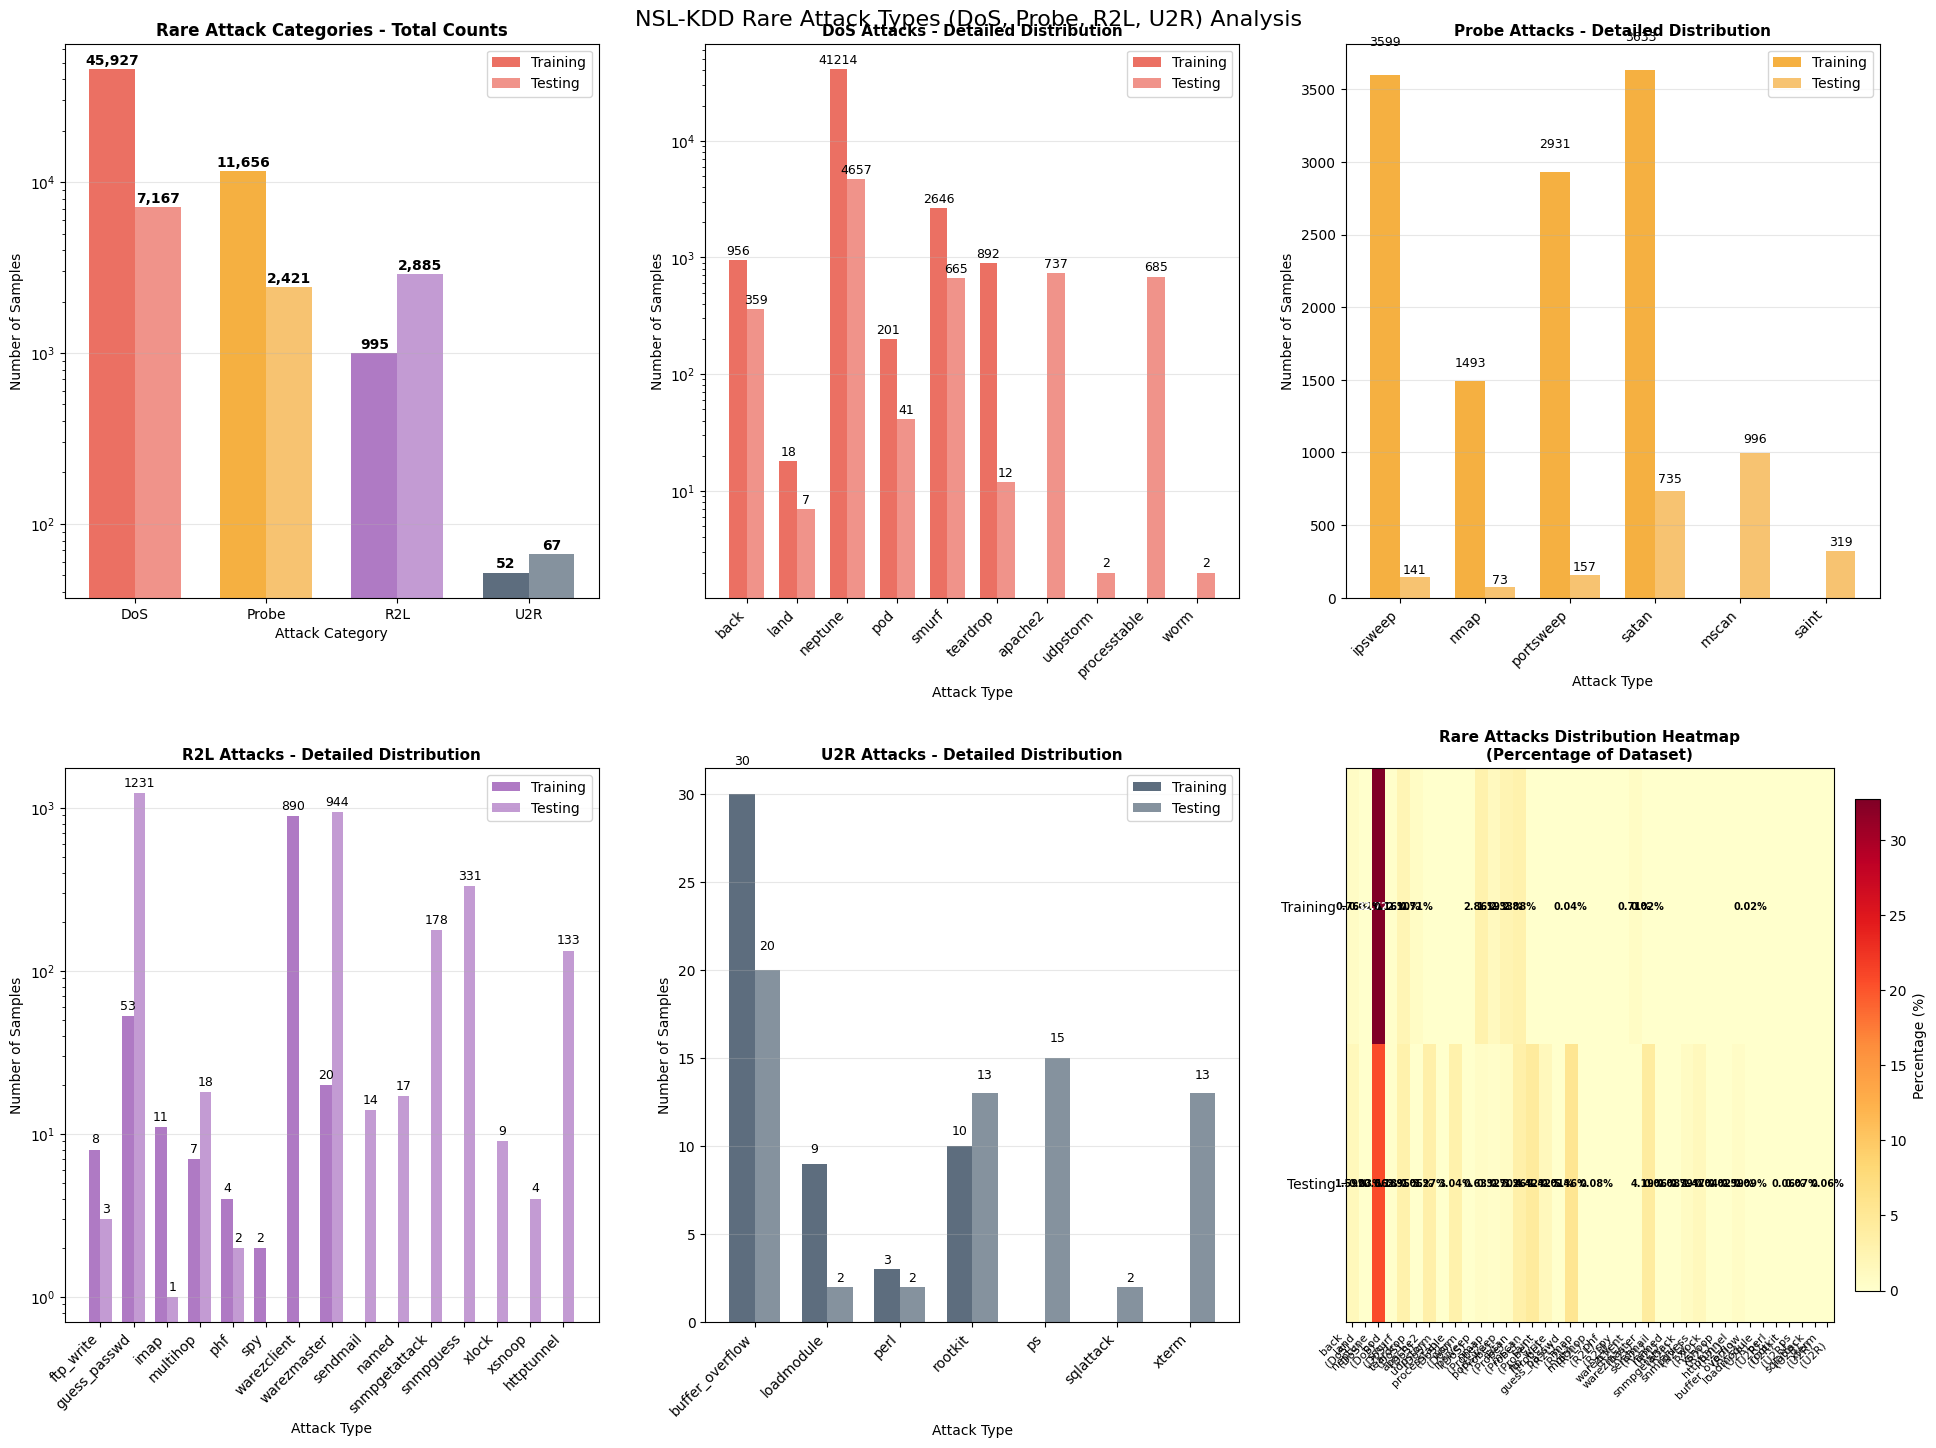

Combined rare attacks analysis saved as 'nsl_kdd_rare_attacks_combined.png'


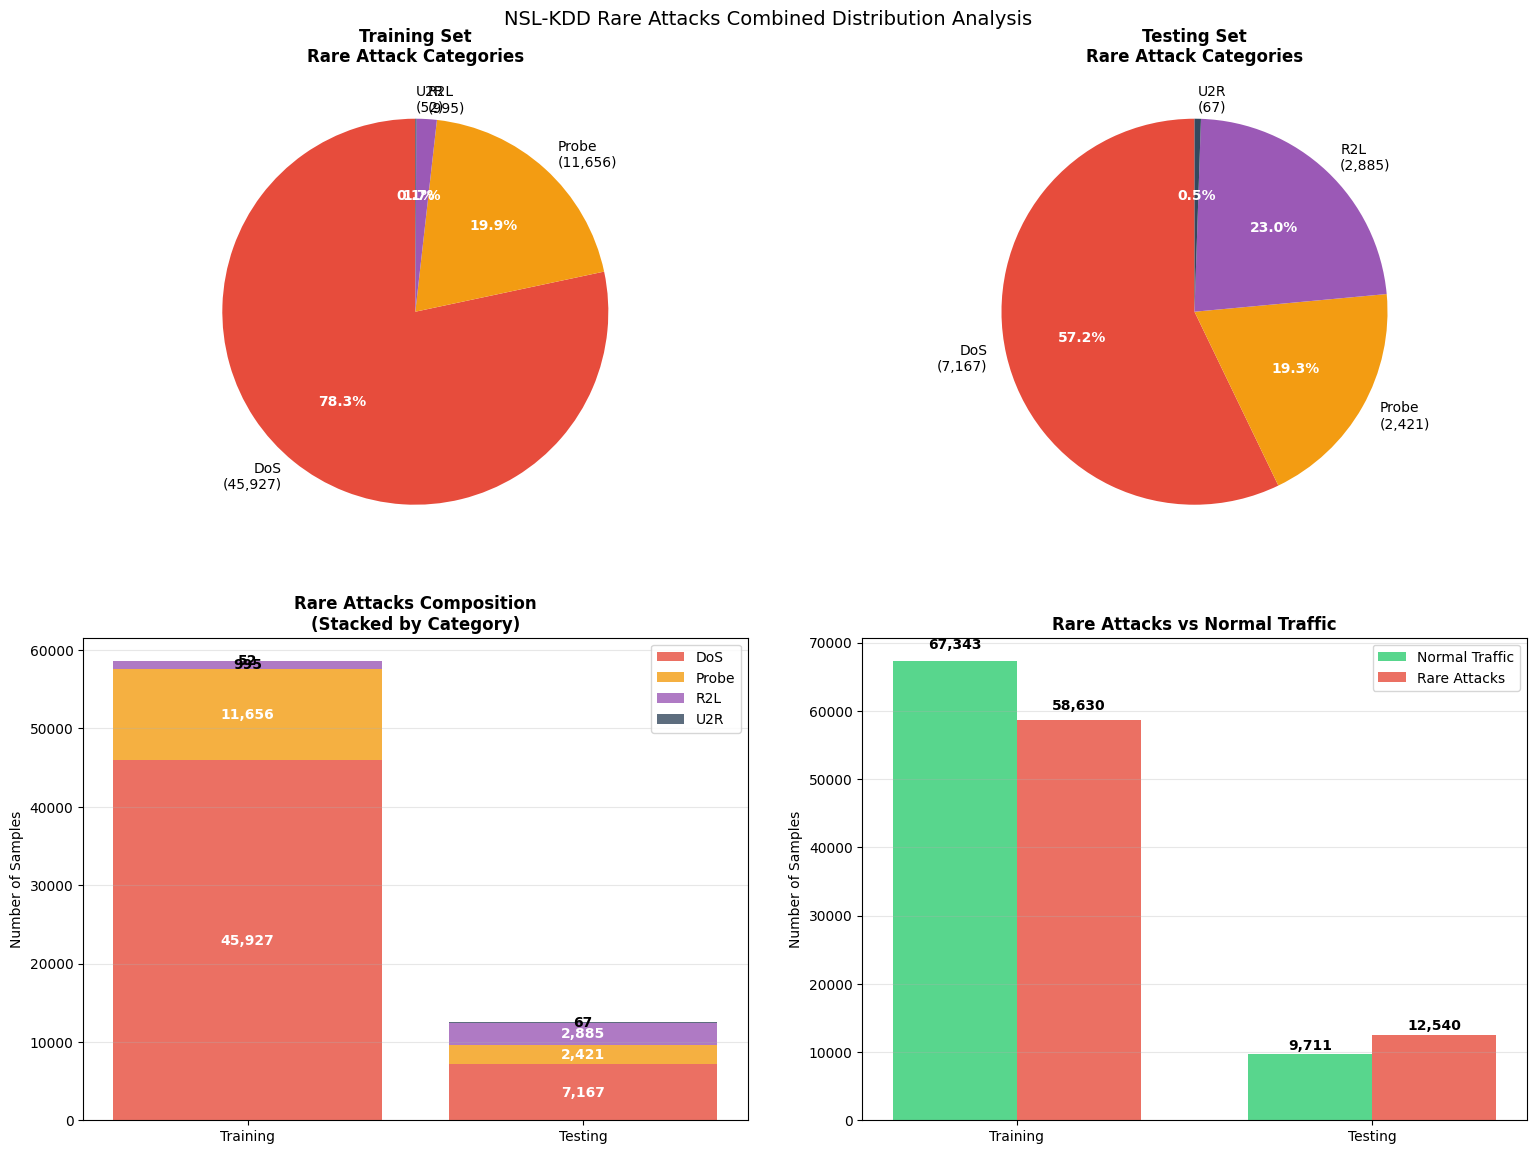

In [10]:
results = analyze_rare_attacks(train_data, test_data)

# Comprehensive visualization
plot_rare_attacks_overview(train_data, test_data, save_plots=True)

# Combined distribution plots
create_combined_distribution_plot(train_data, test_data, save_plots=True)